<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/Temp-Fenya/notebooks/Modern_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fundamental setup

In [1]:
# import collection

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import torch.optim as optim
from tqdm.auto import tqdm
import torch.nn.functional as F

import random

import matplotlib.pyplot as plt

from scipy.sparse import find

In [2]:
#set seed for reproducibility
random_state = 42

def set_seed(random_state=42):
  random.seed(random_state)
  np.random.seed(random_state)
  torch.manual_seed(random_state)
  torch.cuda.manual_seed_all(random_state)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed()


In [3]:
# connect Drive for data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# set project_dir
project_dir = Path('.') / 'drive' / 'MyDrive' / 'AIA_SkinLesion_Projekt'

In [5]:
#path to image data
data_raw =[
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_1'),
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_2'),
    ]

# load metadata
csv_path    = project_dir / 'HAM10000_metadata_converted.csv'
df_metadata = pd.read_csv(csv_path)

#load splits
csv_train = project_dir / 'splits' / 'train.csv'
df_train  = pd.read_csv(csv_train)

csv_train_balanced = project_dir / 'splits' / 'train_balanced.csv'
df_train_balanced  = pd.read_csv(csv_train_balanced)

csv_test = project_dir / 'splits' / 'test.csv'
df_test  = pd.read_csv(csv_test)

csv_val = project_dir / 'splits' / 'val.csv'
df_val  = pd.read_csv(csv_val)

# Data preprocessing for modern pipeline

In [6]:
# EfficientNet-B0 expects 224x224; other resolutions are possible; includes ImageNet normalization

# define image transformations for train and test/validation set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## function for searching images from drive
def find_image_path(img_id, directories):
    img_name = img_id + '.jpg'
    for directory in directories:
        path = os.path.join(directory, img_name)
        if os.path.exists(path):
            return path
    return None

# Dataset class
class SkinDataset(Dataset):
    def __init__(self, dataframe, img_dirs, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.loc[idx, 'image_id']
        img_name = img_id + '.jpg'
        img_path = find_image_path(img_id, self.img_dirs)

        if img_path is None:
            raise FileNotFoundError(f"Image {img_name} not found!")

        image = Image.open(img_path).convert('RGB')
        label = self.data.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32), img_id

# Use balanced training set if loaded, otherwise use standard df_train
train_set_to_use = df_train_balanced if 'df_train_balanced' in locals() else df_train

# create data sets
train_dataset = SkinDataset(train_set_to_use, data_raw, transform=train_transforms)
val_dataset = SkinDataset(df_val, data_raw, transform=test_transforms)
test_dataset = SkinDataset(df_test, data_raw, transform=test_transforms)

# create data loader
b_size = 32

#reproducibility for DataLoader
g = torch.Generator()
g.manual_seed(random_state)

train_loader = DataLoader(train_dataset, batch_size=b_size, generator=g, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=b_size, shuffle=False)

print(f"Dataset ready. Training uses: {'Balanced Set' if 'df_train_balanced' in locals() else 'Standard Set'}")
print(f"Number of training images: {len(train_dataset)}")

Dataset ready. Training uses: Balanced Set
Number of training images: 2300


Loading original image with id: ISIC_0026610.jpg ...


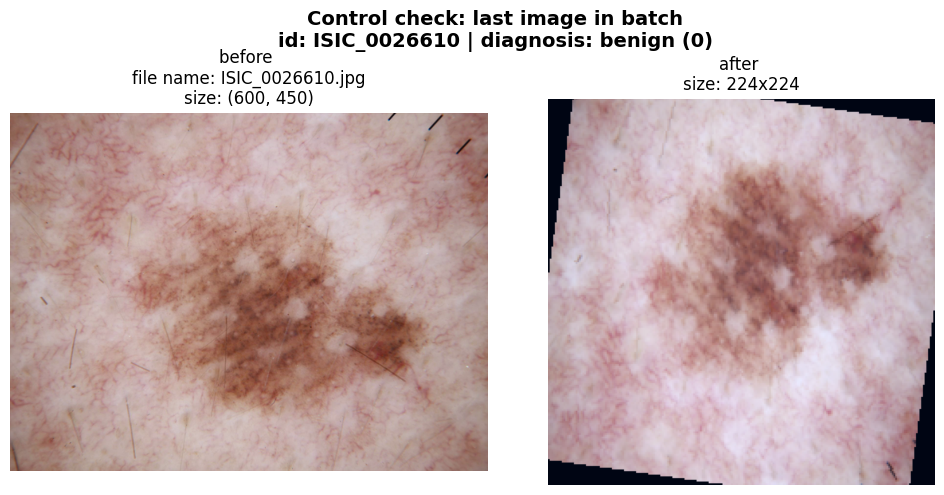

Searched for id: ISIC_0026610
ID from csv:
          image_id  label
8756  ISIC_0026610      0

 Matches csv
finished


In [7]:
### Example output
images, labels, image_ids = next(iter(train_loader))


tensor_img = images[-1]
label = labels[-1]
last_id = image_ids[-1]  # Das ist z.B. "ISIC_0024306"

print(f"Loading original image with id: {last_id}.jpg ...")

# image after transformation
img_np = tensor_img.numpy().transpose((1, 2, 0))
#mean = np.array([0.485, 0.456, 0.406])
#std = np.array([0.229, 0.224, 0.225])
#bild_np = std * bild_np + mean
minimum = img_np.min()
maximum = img_np.max()
img_np = (img_np - minimum) / (maximum - minimum)

# original image
img_name = last_id + '.jpg'
original_path = find_image_path(last_id, data_raw)

# show images
if original_path:
    original_image = Image.open(original_path).convert('RGB')
    label_name = "malignant (1)" if label.item() == 1.0 else "benign (0)"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Control check: last image in batch\nid: {last_id} | diagnosis: {label_name}", fontsize=14, fontweight='bold')

    axes[0].imshow(original_image)
    axes[0].set_title(f"before \nfile name: {img_name}\nsize: {original_image.size}", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_np)
    axes[1].set_title(f"after \nsize: {tensor_img.shape[1]}x{tensor_img.shape[2]}", fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: {img_name} could not be found!")

check_row = df_metadata[df_metadata['image_id'] == last_id]

print(f"Searched for id: {last_id}")
print(f"ID from csv:\n{check_row[['image_id', 'label']]}")

# additional check
csv_label = check_row['label'].values[0]
batch_label = int(label.item())

if csv_label == batch_label:
    print("\n Matches csv")
else:
    print("\n Differs from csv")

print("finished")

```markdown
# Modern Pipeline: EfficientNet-B0

In this section, we implement the EfficientNet-B0 model.
- The feature extractor is frozen (**frozen weights**).
- The classification head is adapted for binary classification.
- For uncertainty estimation, we implement a logic for **Monte Carlo (MC) Dropout**.
```

In [9]:
def get_efficientnet_model(dropout_rate=0.5):
    # 1. Load pre-trained EfficientNet-B0 weights from ImageNet
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')

    # 2. Freeze backbone: Prevent weights from updating during training
    for param in model.parameters():
        param.requires_grad = False

    # 3. Adapt classification head for binary output (1 neuron)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        ###deeper classification head for non linear separating
        nn.Dropout(p=dropout_rate),
        nn.Linear(num_ftrs, 128),
        nn.ReLU(),
        ### end deeper classification head
        nn.Dropout(p=dropout_rate),
        nn.Linear(128, 1)
    )

    return model

# Initialize model and move to GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_efficientnet_model()
model = model.to(device)

print(f"Model loaded on {device}.")
# Check trainable params: should only be the new classifier head
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters (head only): {trainable_params}")

Model loaded on cuda.
Trainable parameters (head only): 164097


```markdown
### Note on MC Dropout
To measure uncertainty later, we must ensure that Dropout remains active even during the test phase (`model.eval()`). We achieve this by manually setting the Dropout layers back to `.train()`.
```

### Schritt 1: Das Modell für Fine-Tuning konfigurieren

In [10]:
def enable_dropout(m):
    """
    Forces Dropout layers to stay in .train() mode even during evaluation.
    This allows for Monte Carlo (MC) sampling to estimate uncertainty.
    """
    for module in m.modules():
        if isinstance(module, nn.Dropout):
            module.train()

## Training and Validation with frozen Backbone
We define the loss function (BCEWithLogitsLoss), the optimizer (Adam), and a loop to train and validate the model across several epochs.


In [12]:
# --- SETTINGS ---
# freshly load model
set_seed()
model = get_efficientnet_model()
model = model.to(device)

num_epochs = 40
learning_rate = 0.001
# TIP: Set limit_batches to 1 for a quick test run. Set to None for full training.
limit_batches = None
save_weights = False # FLAG: Set to True only when you want to export the model file
save_path = project_dir / 'models' / 'efficientnet_skin_model_weights.pth'

#for early stopping
patience = 7  # number of epochs without further improvement
min_delta = 0.0 #min value for improvement


# 2. Loss and Optimizer setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=learning_rate)

# 3. Training Loop
train_losses = []
val_losses = []
train_acc = []
val_acc = []

#for early stopping
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

#start training
print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() #does mc dropout todo check --> enable dropout bisher nicht aufgerufen
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    # Removed tqdm for GitHub compatibility
    for i, (images, labels, _) in enumerate(train_loader):
        if limit_batches and i >= limit_batches: break

        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0) #in case last batch is smaller than others
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_correct += (preds == labels).sum().item()

    #epoch_train_loss = running_loss / (len(train_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_correct / total_samples
    train_losses.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    running_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for i, (images, labels, _) in enumerate(val_loader):
            if limit_batches and i >= limit_batches: break

            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_val_loss += loss.item() * batch_size
            total_val_samples += batch_size

            preds = (torch.sigmoid(outputs) > 0.5).float()
            running_val_correct += (preds == labels).sum().item()



    epoch_val_loss = running_val_loss / (len(val_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_val_acc = running_val_correct / total_val_samples
    val_losses.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] completed. "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Check early stopping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  -> new best val loss: {best_val_loss:.4f} (saved model)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epochs.")

        if epochs_no_improve >= patience:
            print(f"\nEarly Stopping after epoch {epoch+1}. "
                  f"Best Val Loss: {best_val_loss:.4f}")
            break



# 4. Optional Saving
if (save_weights and (best_model_state is not None)):
    #load best model
    model.load_state_dict(best_model_state)
    print("Best model (based on val loss) rebuilt.")

    #save model
    os.makedirs(save_path.parent, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
else:
    print("Run finished! Last weights were kept in RAM only.")

Starting training on cuda...


KeyboardInterrupt: 

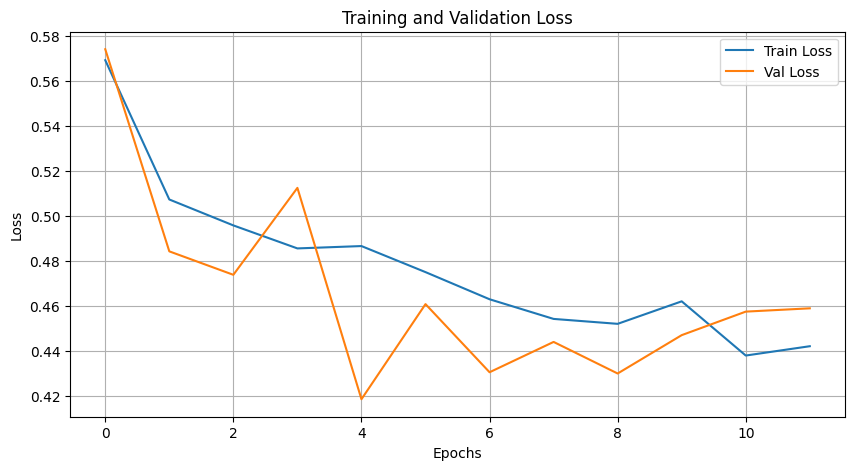

In [ ]:
# Visualize training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Training with Unfrozen backbone

In [ ]:
#freshly load model
set_seed()
model = get_efficientnet_model()
model = model.to(device)
unfreeze_backbone = True #used in test set

# unfreeze backbone
layers_to_unfreeze = ["features.7", "features.8", "classifier"]  ##for unfreezing more layer, just add features.<layernumber>


for name, param in model.named_parameters():
    if any(x in name for x in layers_to_unfreeze):
        param.requires_grad = True
    else:
        param.requires_grad = False

# --- SETTINGS --- ##duplicated from frozen backbone

num_epochs = 40
learning_rate = 0.0001
# TIP: Set limit_batches to 1 for a quick test run. Set to None for full training.
limit_batches = None
save_weights = True # FLAG: Set to True only when you want to export the model file
save_path = project_dir / 'models' / 'efficientnet_finetuned_backbone.pth'

#for early stopping
patience = 7  # number of epochs without further improvement
min_delta = 0.0 #min value for improvement

# 2. Loss and Optimizer setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)  ###adapted for unfrozen pipeline

# 3. Training Loop
train_losses = []
val_losses = []
train_acc = []
val_acc = []

#for early stopping
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

#start training
print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() #does mc dropout todo check --> enable dropout bisher nicht aufgerufen
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    # Removed tqdm for GitHub compatibility
    for i, (images, labels, _) in enumerate(train_loader):
        if limit_batches and i >= limit_batches: break

        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0) #in case last batch is smaller than others
        running_loss += loss.item() * batch_size
        total_samples += batch_size

        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_correct += (preds == labels).sum().item()

    #epoch_train_loss = running_loss / (len(train_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_train_loss = running_loss / total_samples
    epoch_train_acc = running_correct / total_samples
    train_losses.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    running_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for i, (images, labels, _) in enumerate(val_loader):
            if limit_batches and i >= limit_batches: break

            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_val_loss += loss.item() * batch_size
            total_val_samples += batch_size

            preds = (torch.sigmoid(outputs) > 0.5).float()
            running_val_correct += (preds == labels).sum().item()



    epoch_val_loss = running_val_loss / (len(val_loader.dataset) if not limit_batches else (limit_batches * b_size))
    epoch_val_acc = running_val_correct / total_val_samples
    val_losses.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] completed. "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # Check early stopping
    if epoch_val_loss < best_val_loss - min_delta:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  -> new best val loss: {best_val_loss:.4f} (saved model)")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epochs.")

        if epochs_no_improve >= patience:
            print(f"\nEarly Stopping after epoch {epoch+1}. "
                  f"Best Val Loss: {best_val_loss:.4f}")
            break



# 4. Optional Saving
if (save_weights and (best_model_state is not None)):
    #load best model
    model.load_state_dict(best_model_state)
    print("Best model (based on val loss) rebuilt.")

    #save model
    os.makedirs(save_path.parent, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Model saved to {save_path}")
else:
    print("Run finished! Last weights were kept in RAM only.")

Starting training on cuda...
Epoch [1/40] completed. Train Loss: 0.6491 | Train Acc: 0.6539 | Val Loss: 0.6048 | Val Acc: 0.6568
  -> new best val loss: 0.6048 (saved model)
Epoch [2/40] completed. Train Loss: 0.5281 | Train Acc: 0.7378 | Val Loss: 0.5172 | Val Acc: 0.6711
  -> new best val loss: 0.5172 (saved model)
Epoch [3/40] completed. Train Loss: 0.4746 | Train Acc: 0.7557 | Val Loss: 0.4854 | Val Acc: 0.6956
  -> new best val loss: 0.4854 (saved model)
Epoch [4/40] completed. Train Loss: 0.4514 | Train Acc: 0.7678 | Val Loss: 0.4868 | Val Acc: 0.7079
  -> No improvement for 1 epochs.
Epoch [5/40] completed. Train Loss: 0.4246 | Train Acc: 0.7865 | Val Loss: 0.4857 | Val Acc: 0.7344
  -> No improvement for 2 epochs.
Epoch [6/40] completed. Train Loss: 0.4252 | Train Acc: 0.7848 | Val Loss: 0.4571 | Val Acc: 0.7446
  -> new best val loss: 0.4571 (saved model)
Epoch [7/40] completed. Train Loss: 0.4032 | Train Acc: 0.7965 | Val Loss: 0.4535 | Val Acc: 0.7600
  -> new best val loss:

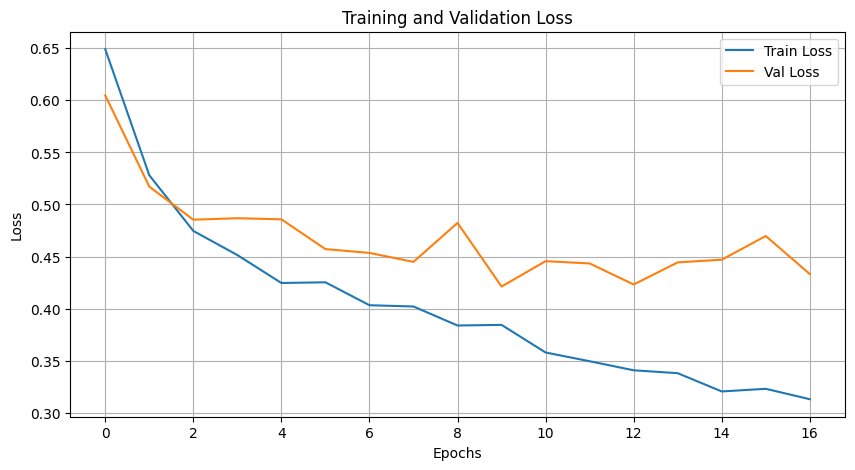

In [ ]:
# Visualize training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 📂 Loading Saved Weights
Use this block if you want to load a previously trained model from your Google Drive instead of running a new training.

In [ ]:
# 1. Define file path
weights_path = project_dir / 'models' / 'efficientnet_skin_model_weights.pth'
# alternative: weoghts with unfrozen backbone
# weights_path = project_dir / 'models' / 'efficientnet_finetuned_backbone.pth'

# 2. Check if file exists
if weights_path.exists():
    # 3. Load the weights (state_dict)
    # map_location='cpu' allows loading even without a GPU
    state_dict = torch.load(weights_path, map_location=device)

    # 4. Transfer weights into the model
    model.load_state_dict(state_dict)
    model.to(device)

    print(f"Weights successfully loaded from {weights_path}.")
else:
    print(f"No weight file found at {weights_path}. Did you use 'save_weights = True' during training?")

✅ Weights successfully loaded from drive/MyDrive/AIA_SkinLesion_Projekt/models/efficientnet_skin_model_weights.pth.


In [ ]:


def predict_with_uncertainty(model, dataloader, num_samples=10):
    """ Performs MC Dropout by running multiple forward passes """
    model.eval()
    enable_dropout(model) # Keep Dropout active

    images, labels, ids = next(iter(dataloader))
    images = images.to(device)

    with torch.no_grad():
        # Collect predictions from multiple passes
        outputs = torch.stack([model(images) for _ in range(num_samples)])
        probs = torch.sigmoid(outputs)

    mean_probs = probs.mean(dim=0).cpu().numpy()
    std_probs = probs.std(dim=0).cpu().numpy()

    return images.cpu(), labels.numpy(), mean_probs, std_probs, ids

# --- Demonstration ---
imgs, lbls, means, stds, img_ids = predict_with_uncertainty(model, val_loader)

idx = 0
print(f"Image ID: {img_ids[idx]}")
print(f"True Label: {'Malignant' if lbls[idx] == 1 else 'Benign'}")
print(f"Model Prediction (Mean Prob): {means[idx][0]:.4f}")
print(f"Uncertainty (Std Dev): {stds[idx][0]:.4f}")

Image ID: ISIC_0029176
True Label: Benign
Model Prediction (Mean Prob): 0.5352
Uncertainty (Std Dev): 0.0247


###### precision & recall über gesamtes Val set

In [ ]:

def evaluate_with_uncertainty(model, dataloader, num_samples=10):
    """ Performs MC Dropout over the full dataloader and computes
        precision/recall alongside mean predictions and uncertainty. """
    model.eval()
    enable_dropout(model)  # Keep Dropout active

    all_means = []
    all_stds = []
    all_labels = []
    all_ids = []

    with torch.no_grad():
        for images, labels, ids in dataloader:
            images = images.to(device)

            # Collect predictions from multiple stochastic passes
            outputs = torch.stack([model(images) for _ in range(num_samples)])
            probs = torch.sigmoid(outputs)

            mean_probs = probs.mean(dim=0).cpu().numpy()
            std_probs = probs.std(dim=0).cpu().numpy()

            all_means.append(mean_probs)
            all_stds.append(std_probs)
            all_labels.append(labels.numpy())
            all_ids.extend(ids)

    all_means = np.concatenate(all_means, axis=0)
    all_stds = np.concatenate(all_stds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_means, all_stds, all_labels, all_ids


def compute_precision_recall(mean_probs, true_labels, threshold=0.5):
    """ Computes precision and recall for binary classification. """
    preds = (mean_probs.squeeze() > threshold).astype(int)
    labels = true_labels.astype(int)

    true_positives = ((preds == 1) & (labels == 1)).sum()
    false_positives = ((preds == 1) & (labels == 0)).sum()
    false_negatives = ((preds == 0) & (labels == 1)).sum()

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0.0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0.0

    return precision, recall


# --- Demonstration ---
means, stds, labels, img_ids = evaluate_with_uncertainty(model, val_loader)

precision, recall = compute_precision_recall(means, labels)
print(f"Validation Precision (False Positives): {precision:.4f}")
print(f"Validation Recall (Detection rate malignant): {recall:.4f}")

# Einzelbeispiel weiterhin möglich
idx = 0
print(f"\nImage ID: {img_ids[idx]}")
print(f"True Label: {'Malignant' if labels[idx] == 1 else 'Benign'}")
print(f"Model Prediction (Mean Prob): {means[idx][0]:.4f}")
print(f"Uncertainty (Std Dev): {stds[idx][0]:.4f}")

Validation Precision (False Positives): 0.4533
Validation Recall (Detection rate malignant): 0.8293

Image ID: ISIC_0029176
True Label: Benign
Model Prediction (Mean Prob): 0.5367
Uncertainty (Std Dev): 0.0445


In [ ]:
import pandas as pd

# Hier kannst du beliebig viele Werte testen, ohne neu validieren zu müssen
test_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for t in test_thresholds:
    p, r = compute_precision_recall(means, labels, threshold=t)
    results.append({
        'Threshold': t,
        'Precision (Vermeidung Fehlalarme)': f"{p:.2%}",
        'Recall (Erkennung Maligne)': f"{r:.2%}"
    })

# Darstellung als übersichtliche Tabelle
df_thresholds_clean = pd.DataFrame(results)
display(df_thresholds_clean)

print("\nHinweis: Nutze diese Tabelle, um den besten Kompromiss für dein Projekt zu finden.")

,Threshold,Precision (Vermeidung Fehlalarme),Recall (Erkennung Maligne)
0,0.1,28.19%,96.95%
1,0.2,32.51%,96.34%
2,0.3,35.92%,93.29%
3,0.4,40.76%,91.46%
4,0.5,45.33%,82.93%
5,0.6,50.43%,71.95%
6,0.7,52.63%,54.88%
7,0.8,56.25%,38.41%
8,0.9,67.92%,21.95%



Hinweis: Nutze diese Tabelle, um den besten Kompromiss für dein Projekt zu finden.


Validation Precision (False Positives): 0.4623
Validation Recall (False Negatives): 0.8232
--> Malignant is okayish detected, we have more false positives

## Final Evaluation on Test Set
Execute this cell ONLY after you have performed a full training run (with `limit_batches = None`).

In [ ]:
def evaluate_test_set(model, dataloader):
    model.eval()
    # Note: We do NOT use enable_dropout here for the standard 'final' performance,
    # unless you want the mean of MC Dropout samples as your final prediction.

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader, desc="Evaluating Test Set"):
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

# Run evaluation
# labels_test, preds_test = evaluate_test_set(model, test_loader)
# print("Evaluation finished. You can now calculate metrics like AUC-ROC.")

### MC Dropout Evaluation on Test Set
This cell applies MC Dropout to the entire Test Set to get uncertainty estimates for every final prediction.

In [ ]:
def evaluate_test_set_with_uncertainty(model, dataloader, num_samples=10):
    model.eval()
    enable_dropout(model) # Ensure Dropout stays active

    all_means = []
    all_stds = []
    all_labels = []
    all_ids = []

    print(f"Starte MC Dropout Evaluation ({num_samples} Durchläufe pro Bild)... ")

    with torch.no_grad():
        for i, (images, labels, ids) in enumerate(dataloader):
            images = images.to(device)

            # Multiple forward passes
            outputs = torch.stack([model(images) for _ in range(num_samples)])
            probs = torch.sigmoid(outputs)

            mean_probs = probs.mean(dim=0).cpu().numpy()
            std_probs = probs.std(dim=0).cpu().numpy()

            all_means.extend(mean_probs)
            all_stds.extend(std_probs)
            all_labels.extend(labels.numpy())
            all_ids.extend(ids)

            # Text-basiertes Log alle 10 Batches statt tqdm-Ladebalken
            if (i + 1) % 10 == 0:
                print(f"Batch {i+1}/{len(dataloader)} verarbeitet...")

    return np.array(all_ids), np.array(all_labels), np.array(all_means), np.array(all_stds)

## 🏁 Final Step: Inference on the Test Set
After your full training is complete, run this cell to get the final results for your project report.

In [ ]:
# 1. Dateinamen basierend auf dem Modus festlegen
suffix = "unfrozen" if (locals().get('unfreeze_backbone', False)) else "frozen"
filename = f'final_test_results_{suffix}_backbone_modern.csv'
output_path = project_dir / filename

print(f"--- Finale Test-Evaluation ({suffix.upper()}) ---")

# 2. Run the evaluation
# Nutzt jetzt die bereinigte Funktion ohne tqdm
test_ids, test_labels, test_means, test_stds = evaluate_test_set_with_uncertainty(model, test_loader, num_samples=20)

# 3. DataFrame erstellen
results_df = pd.DataFrame({
    'image_id': test_ids,
    'true_label': test_labels,
    'prediction_prob': test_means.flatten(),
    'uncertainty_std': test_stds.flatten()
})

# 4. Anzeige und Speichern
display(results_df.head())
results_df.to_csv(output_path, index=False)
print(f"\n✅ Ergebnisse gespeichert: {output_path}")

--- Finale Test-Evaluation (UNFROZEN) ---
Starte MC Dropout Evaluation (20 Durchläufe pro Bild)... 
Batch 10/60 verarbeitet...
Batch 20/60 verarbeitet...
Batch 30/60 verarbeitet...
Batch 40/60 verarbeitet...
Batch 50/60 verarbeitet...
Batch 60/60 verarbeitet...


,image_id,true_label,prediction_prob,uncertainty_std
0,ISIC_0025033,0.0,0.201358,0.092536
1,ISIC_0027310,0.0,0.438843,0.050803
2,ISIC_0032128,0.0,0.601140,0.078546
3,ISIC_0025937,0.0,0.510468,0.059494
4,ISIC_0031753,0.0,0.468200,0.028751



✅ Ergebnisse gespeichert: drive/MyDrive/AIA_SkinLesion_Projekt/final_test_results_unfrozen_backbone_modern.csv


```markdown
### 📂 Load Existing Test Results
Use this cell to load results from Drive if you have already performed the inference before and just want to re-evaluate the metrics.
```

In [ ]:
# Wählen Sie hier, welche Ergebnisse geladen werden sollen
load_suffix = "frozen"  # Oder "unfrozen"
load_path = project_dir / f'final_test_results_{load_suffix}_backbone_modern.csv'

if load_path.exists():
    results_frozen_df = pd.read_csv(load_path)
    print(f"✅ Ergebnisse erfolgreich aus Drive geladen: {load_path}")
    display(results_frozen_df.head())
else:
    print(f"⚠️ Datei nicht gefunden: {load_path}. Hast du den Test bereits einmal durchlaufen lassen?")

load_suffix = "unfrozen"  # Oder "unfrozen"
load_path = project_dir / f'final_test_results_{load_suffix}_backbone_modern.csv'

if load_path.exists():
    results_unfrozen_df = pd.read_csv(load_path)
    print(f"✅ Ergebnisse erfolgreich aus Drive geladen: {load_path}")
    display(results_unfrozen_df.head())
else:
    print(f"⚠️ Datei nicht gefunden: {load_path}. Hast du den Test bereits einmal durchlaufen lassen?")

✅ Ergebnisse erfolgreich aus Drive geladen: drive/MyDrive/AIA_SkinLesion_Projekt/final_test_results_frozen_backbone_modern.csv


,image_id,true_label,prediction_prob,uncertainty_std
0,ISIC_0025033,0.0,0.551187,0.149273
1,ISIC_0027310,0.0,0.557203,0.111300
2,ISIC_0032128,0.0,0.547245,0.077717
3,ISIC_0025937,0.0,0.449618,0.119998
4,ISIC_0031753,0.0,0.595734,0.136276


✅ Ergebnisse erfolgreich aus Drive geladen: drive/MyDrive/AIA_SkinLesion_Projekt/final_test_results_unfrozen_backbone_modern.csv


,image_id,true_label,prediction_prob,uncertainty_std
0,ISIC_0025033,0.0,0.201358,0.092536
1,ISIC_0027310,0.0,0.438843,0.050803
2,ISIC_0032128,0.0,0.601140,0.078546
3,ISIC_0025937,0.0,0.510468,0.059494
4,ISIC_0031753,0.0,0.468200,0.028751


In [ ]:
# Schwellenwert festlegen (0.3 wurde in der Validierung als gut identifiziert)
test_threshold = 0.3 # frozen 0.3 unfrozen 0.3/0.4?

# Berechnungen
preds_test = (results_frozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_frozen_df['true_label'].astype(int)

tp = ((preds_test == 1) & (labels_test == 1)).sum()
fp = ((preds_test == 1) & (labels_test == 0)).sum()
fn = ((preds_test == 0) & (labels_test == 1)).sum()
tn = ((preds_test == 0) & (labels_test == 0)).sum()

test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
test_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
test_accuracy = (tp + tn) / len(results_frozen_df)

print(f"--- Test-Performance frozen (Threshold: {test_threshold}) ---")
print(f"Precision: {test_precision:.2%}")
print(f"Recall:    {test_recall:.2%}")
print(f"Accuracy:  {test_accuracy:.2%}")
print(f"\nZusammenfassung: Das Modell erkennt {test_recall:.2%} aller bösartigen Läsionen im Test-Set.")

preds_test = (results_unfrozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_unfrozen_df['true_label'].astype(int)

tp = ((preds_test == 1) & (labels_test == 1)).sum()
fp = ((preds_test == 1) & (labels_test == 0)).sum()
fn = ((preds_test == 0) & (labels_test == 1)).sum()
tn = ((preds_test == 0) & (labels_test == 0)).sum()

test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
test_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
test_accuracy = (tp + tn) / len(results_unfrozen_df)

print(f"--- Test-Performance unfrozen (Threshold: {test_threshold}) ---")
print(f"Precision: {test_precision:.2%}")
print(f"Recall:    {test_recall:.2%}")
print(f"Accuracy:  {test_accuracy:.2%}")
print(f"\nZusammenfassung: Das Modell erkennt {test_recall:.2%} aller bösartigen Läsionen im Test-Set.")

--- Test-Performance frozen (Threshold: 0.3) ---
Precision: 29.63%
Recall:    96.17%
Accuracy:  62.08%

Zusammenfassung: Das Modell erkennt 96.17% aller bösartigen Läsionen im Test-Set.
--- Test-Performance unfrozen (Threshold: 0.3) ---
Precision: 33.76%
Recall:    92.33%
Accuracy:  69.17%

Zusammenfassung: Das Modell erkennt 92.33% aller bösartigen Läsionen im Test-Set.


### Konfusionsmatrix

Die Konfusionsmatrix zeigt detailliert, wie viele Vorhersagen korrekt (True Positives, True Negatives) und falsch (False Positives, False Negatives) waren.

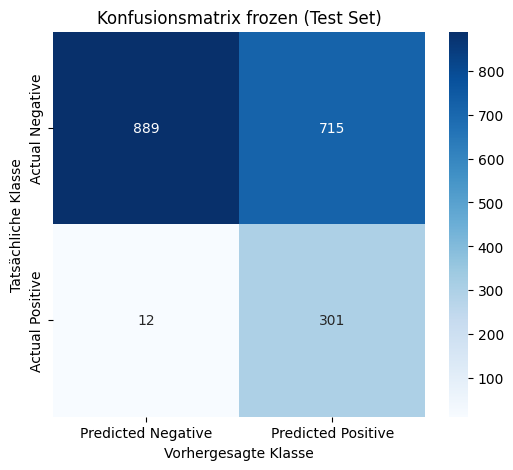

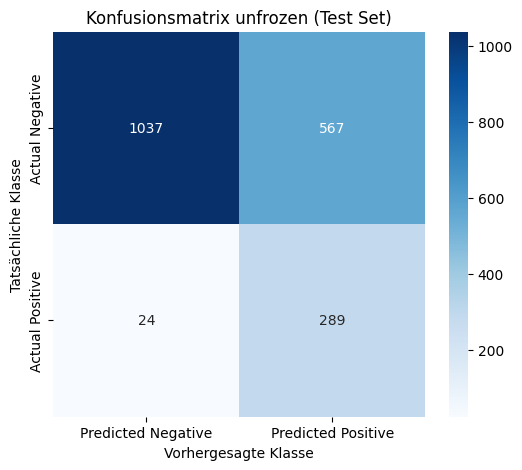

In [ ]:
preds_test = (results_frozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_frozen_df['true_label'].astype(int)

# Konfusionsmatrix erstellen
cm = confusion_matrix(labels_test, preds_test)

# Visualisierung der Konfusionsmatrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Konfusionsmatrix frozen (Test Set)')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Tatsächliche Klasse')
plt.show()


preds_test = (results_unfrozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_unfrozen_df['true_label'].astype(int)
# Konfusionsmatrix erstellen
cm = confusion_matrix(labels_test, preds_test)

# Visualisierung der Konfusionsmatrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Konfusionsmatrix unfrozen (Test Set)')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Tatsächliche Klasse')
plt.show()

### ROC-Kurve und AUC

Die ROC-Kurve (Receiver Operating Characteristic) zeigt die True Positive Rate (TPR) gegen die False Positive Rate (FPR) bei verschiedenen Schwellenwerten. Der Bereich unter der Kurve (AUC) ist ein Maß für die Diskriminierungsfähigkeit des Modells.

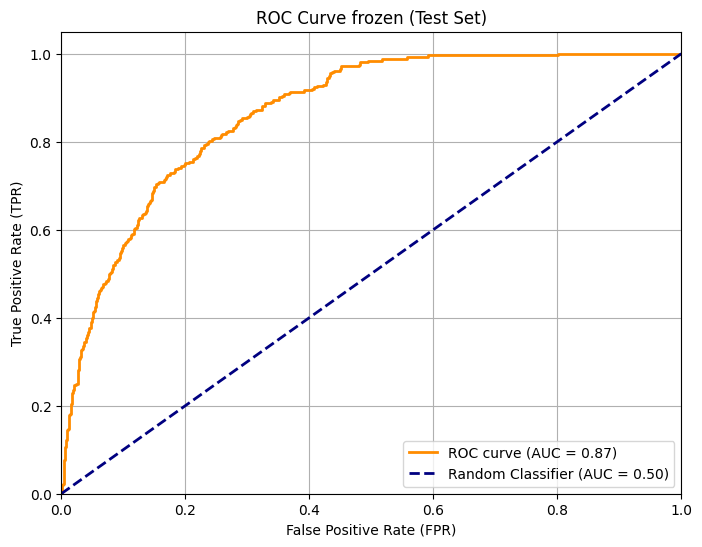

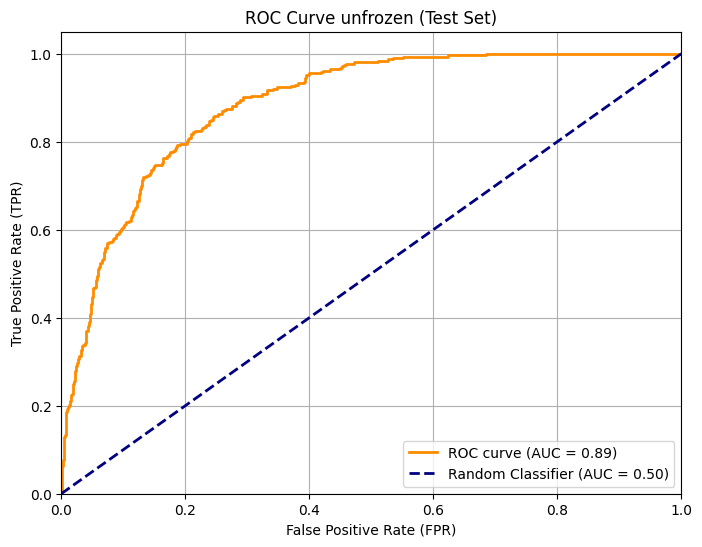

In [ ]:
preds_test = (results_frozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_frozen_df['true_label'].astype(int)
# ROC-Kurve berechnen
fpr, tpr, thresholds = roc_curve(labels_test, results_frozen_df['prediction_prob'])
roc_auc = auc(fpr, tpr)

# Visualisierung der ROC-Kurve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve frozen (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


preds_test = (results_unfrozen_df['prediction_prob'] > test_threshold).astype(int)
labels_test = results_unfrozen_df['true_label'].astype(int)
# ROC-Kurve berechnen
fpr, tpr, thresholds = roc_curve(labels_test, results_unfrozen_df['prediction_prob'])
roc_auc = auc(fpr, tpr)

# Visualisierung der ROC-Kurve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve unfrozen (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()